In [1]:
!pip install -q  duckrun

In [2]:
ws                    = 'vorder'
lh                    = 'storage'
bim_url               = "https://raw.githubusercontent.com/djouallah/fabric_demo/refs/heads/main/semantic_model/directlake.bim"
delta_path            = f"abfss://{ws}@onelake.dfs.fabric.microsoft.com/{lh}.Lakehouse/Tables/dbo/resultsss"  
model_to_test         = ["spark_vorder","spark_default","deltars"]

Minor Modification from https://github.com/microsoft/fabric-toolbox/tree/main/tools/FabricLoadTestTool

In [3]:
from   deltalake            import DeltaTable
from   deltalake.writer     import write_deltalake
from   notebookutils.common import configs
from   psutil               import *
import duckrun
from   psutil import *
import matplotlib.pyplot  as plt
import time 
import duckdb
import os
core              = cpu_count()
Nbr_threads = core * 2
configs.tokenCacheEnabled = False
print(core)

2


In [4]:
conn = duckrun.connect(ws)
conn.import_notebook_from_web(url="https://raw.githubusercontent.com/djouallah/fabric_demo/refs/heads/main/Benchmark/RunPerfScenario.ipynb")

🔐 Getting Fabric API token...
📓 Microsoft Fabric notebook detected - using notebookutils
✅ Fabric API token obtained!
🔍 Resolving workspace: vorder
✓ Found workspace: vorder
📝 Using notebook name from URL: RunPerfScenario


{'success': True,
 'message': "Notebook 'RunPerfScenario' already exists (use overwrite=True to replace)",
 'notebook': {'id': '291ce30d-0481-4828-8445-69ff0b5395b6',
  'type': 'Notebook',
  'displayName': 'RunPerfScenario',
  'description': '',
  'workspaceId': '3cd264b3-4329-41b3-8f54-b3ef6d9ad173'},
 'overwritten': False}

# Test

In [5]:
queryfile           = "https://raw.githubusercontent.com/djouallah/fabric_demo/refs/heads/main/Benchmark/PowerBIPerformanceData3.json"   
concurrent_threads  = 1  
totalrows           = 130124552
load_test_name      = "loadtest"                                                                                                                                                                
delay_sec           = 4                                                                               
iterations          = 1    

In [6]:
def run_dax(workspace,dataset,cache,nbr_queries):
    if 'Collapse Here':
        ts=time.strftime("%Y%m%d-%H%M%S")
        loadtestId:str = f"{load_test_name}-{ts}"
        print(loadtestId)
        users = []
        args = { 
            "xmla_endpoint" : f"powerbi://api.powerbi.com/v1.0/myorg/{workspace}", #defaults to current workspace's endpoint
            "perf_analyzer_filename" : queryfile , 
            "model" : dataset,
            "roles" : None,
            "customdata" : None,
            "effective_username" : None,
            "iterations" : iterations,
            "delay_sec" : 1,
            "loadtestId" : loadtestId ,
            "threadId" : 0 ,
            "concurrent_threads" : concurrent_threads,
            "useRootDefaultLakehouse": True ,
            "cache" : cache ,
            "delta_path" : delta_path,
            "totalrows"  : totalrows,
            "nbr_queries" : nbr_queries
        }

        activity =  {
                    "name": "RunPerfScenario", # activity name, must be unique
                    "path": "RunPerfScenario", # notebook path
                    "timeoutPerCellInSeconds": 90000, # max timeout for each cell, default to 90 seconds
                    "args": {"param1": "value1"}, # notebook parameters
                    "workspace": None, # workspace name, default to current workspace
                    "retry": 0, # max retry times, default to 0
                    "retryIntervalInSeconds": 0, # retry interval, default to 0 seconds
                    "dependencies": [] # list of activity names that this activity depends on
                }


        DAG = {
            "activities": [],
            "timeoutInSeconds": 43200, # max timeout for the entire pipeline, default to 12 hours
            "concurrency": 1 # max number of notebooks to run concurrently, default to 25
        }
        DAG["concurrency"] = concurrent_threads

        for i in range(concurrent_threads):
            a = activity.copy()
            a["name"] = f"{a['name']}_{i}"
            this_args = args.copy()
            if (len(users)>0):
                user = users[i%len(users)]
                this_args["effective_username"] = user 
            this_args["threadId"] = i
            a["args"] = this_args
            DAG["activities"].append(a)
        print('running load test')
        try:
            results = notebookutils.notebook.runMultiple(DAG) 
        except Exception as e:
            first_result = results[list(e.result)[0]]
            print('Notebook failed.  First Result Exception: ')
            print(first_result.get('exception',None))
        print('load test complete')

In [7]:
def run_test(workspace, model_to_test):
    for i, dataset in enumerate(model_to_test):
        try:
            print(dataset)
            duckrun.connect(f"{ws}/{lh}.Lakehouse/{dataset}").deploy(bim_url)
            run_dax(workspace, dataset,0,1)
            time.sleep(300)
            run_dax(workspace, dataset,1,5)
            time.sleep(300)
        except Exception as e:
            print(f"Error: {e}")
    return 'done'

In [8]:
#run_test(ws,model_to_test)

# Result

In [9]:
dt = DeltaTable(delta_path)
dt.optimize.compact()
duckdb.sql(f""" 
                CREATE or replace persistent SECRET onelake ( TYPE AZURE, PROVIDER ACCESS_TOKEN, ACCESS_TOKEN '{notebookutils.credentials.getToken('storage')}') ;
                create or replace table raw
                as select
                *exclude(model),
                model as Engine ,
                from delta_scan('{delta_path}')
                where
                concurrent_threads = {concurrent_threads}
                and iterations = 1   
                and  totalrows = {totalrows}   
                and start_time_dt + INTERVAL '10 hours' > '2025-11-04'    
 """)

In [24]:
pivot_result =duckdb.sql(""" 
         pivot(
         select
         Engine as Parquet_writer,
         cache ,
         query_number ,
         round(avg(duration),2)             AS 'dur'
 from raw 
       where query_number < 6
       group by all
) on cache,query_number using avg(dur)
        """)
duckdb.sql("""
    SELECT 
      *exclude( "0_2","0_3","0_4" ,"0_5" )
    FROM pivot_result
""").show()

┌────────────────┬────────┬────────┬────────┬────────┬────────┬────────┐
│ Parquet_writer │  0_1   │  1_1   │  1_2   │  1_3   │  1_4   │  1_5   │
│    varchar     │ double │ double │ double │ double │ double │ double │
├────────────────┼────────┼────────┼────────┼────────┼────────┼────────┤
│ spark_default  │   5.97 │   2.68 │   0.12 │   0.14 │   0.16 │   0.17 │
│ spark_vorder   │   4.19 │   3.04 │   0.34 │   0.34 │   0.37 │   0.44 │
│ deltars        │   6.29 │   1.95 │   0.12 │   0.13 │   0.14 │   0.16 │
└────────────────┴────────┴────────┴────────┴────────┴────────┴────────┘



In [11]:
summary = duckdb.sql("""
    SELECT
          strftime( DATE_TRUNC('hour', start_time_dt + INTERVAL '10 hours') , '%Y-%m-%d %H%M'  ) AS hour, 
          Engine,
          concurrent_threads,
          max(totalrows)                          AS totalrows,
          COUNT(*)                                AS count,
          round(avg(duration) filter (where query_number =1 and cache =0) ,2) AS cold ,
          round(avg(duration) filter (where cache = 1) ,2)                    AS warm 
      FROM raw
      GROUP BY all
      ORDER BY 1 desc
""")
summary.show(max_width=190)

┌─────────────────┬───────────────┬────────────────────┬───────────┬───────┬────────┬────────┐
│      hour       │    Engine     │ concurrent_threads │ totalrows │ count │  cold  │  warm  │
│     varchar     │    varchar    │       int64        │   int64   │ int64 │ double │ double │
├─────────────────┼───────────────┼────────────────────┼───────────┼───────┼────────┼────────┤
│ 2025-11-05 2200 │ spark_vorder  │                  1 │ 130124552 │     1 │   4.23 │   NULL │
│ 2025-11-05 2100 │ spark_vorder  │                  1 │ 130124552 │     6 │   4.69 │   0.89 │
│ 2025-11-05 2100 │ spark_default │                  1 │ 130124552 │     6 │   6.15 │   0.68 │
│ 2025-11-05 2100 │ deltars       │                  1 │ 130124552 │     6 │   6.44 │   0.54 │
│ 2025-11-05 2000 │ spark_default │                  1 │ 130124552 │     6 │   5.86 │   0.55 │
│ 2025-11-05 2000 │ spark_vorder  │                  1 │ 130124552 │     6 │   4.16 │   0.87 │
│ 2025-11-05 2000 │ deltars       │               

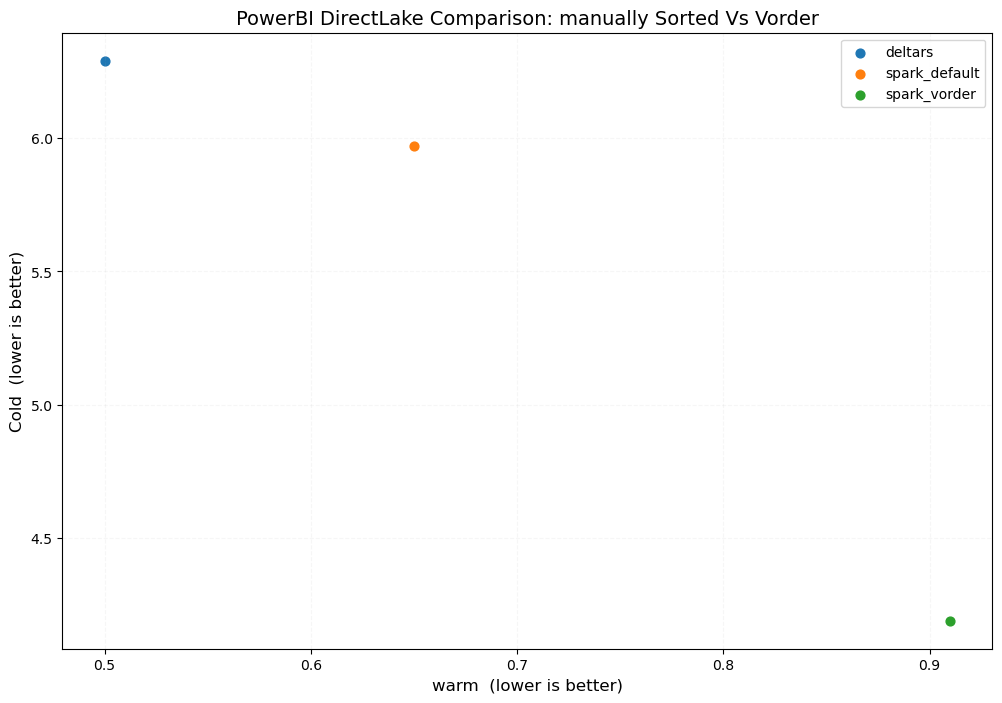

In [12]:
df =duckdb.sql(""" select Engine, round(avg(duration) filter (where query_number =1 and cache =0) ,2) AS cold,
               round(avg(duration) filter (where cache =1),2)  AS warm
                 from raw group by all order by warm asc""").df()
plt.figure(figsize=(12,8 ))
for model, group in df.groupby("Engine"):
    plt.scatter(group["warm"], group["cold"], label=model, s=40)

plt.xlabel("warm  (lower is better)", fontsize=12)
plt.ylabel("Cold  (lower is better)", fontsize=12)
plt.title(" PowerBI DirectLake Comparison: manually Sorted Vs Vorder ", fontsize=14)
plt.legend()
plt.grid(True, linestyle="--", alpha=0.1)
plt.show()